In [7]:
import matplotlib.pyplot as plt
import pandas as pd

In [61]:
df = pd.read_csv('file.csv')

df.head()

,inn,ogrn,region,region_taxcode,creation_date,dissolution_date,age,eligible,exemption_criteria,financial,...,line_1140,line_1150,line_1160,line_1170,line_1180,line_1190,line_1200,line_1210,line_1220,line_1230
0,NaN,9047796688213,moscow city,7700,2004-09-15,NaN,19.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100000011.0,1210100002353,adygeya,100,2021-10-27,NaN,2.0,1.0,none,0.0,...,NaN,203.0,NaN,NaN,NaN,NaN,4537.0,973.0,NaN,3233.0
2,100000036.0,1020100002394,adygeya,100,1990-12-10,2023-04-04,33.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100000043.0,1210100002364,adygeya,100,2021-10-29,NaN,2.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,0.0
4,100000068.0,1210100002375,adygeya,100,2021-10-29,2024-12-24,2.0,1.0,none,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,423.0,93.0,0.0,328.0


### Тут у нас гистограммы для 3-ёх колонок, которые могут содержать полезную информацию.
##### Age для меня и всех понятно, но расшифровать "Okopf" и "Okfc" не смог, но они тоже должны быть ценными.
##### Небольшие выбросы в виде больших значений присущи всем 3-ём колонкам

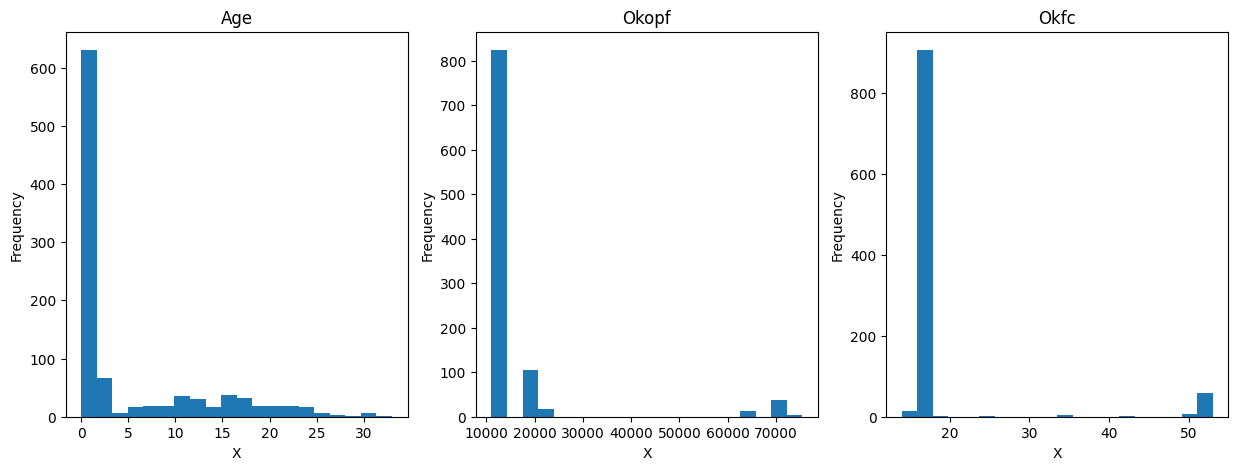

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['age'], bins=20)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age')

axes[1].hist(df['okopf'], bins=20)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Okopf')

axes[2].hist(df['okfc'], bins=20)
axes[2].set_xlabel('X')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Okfc')

plt.show()

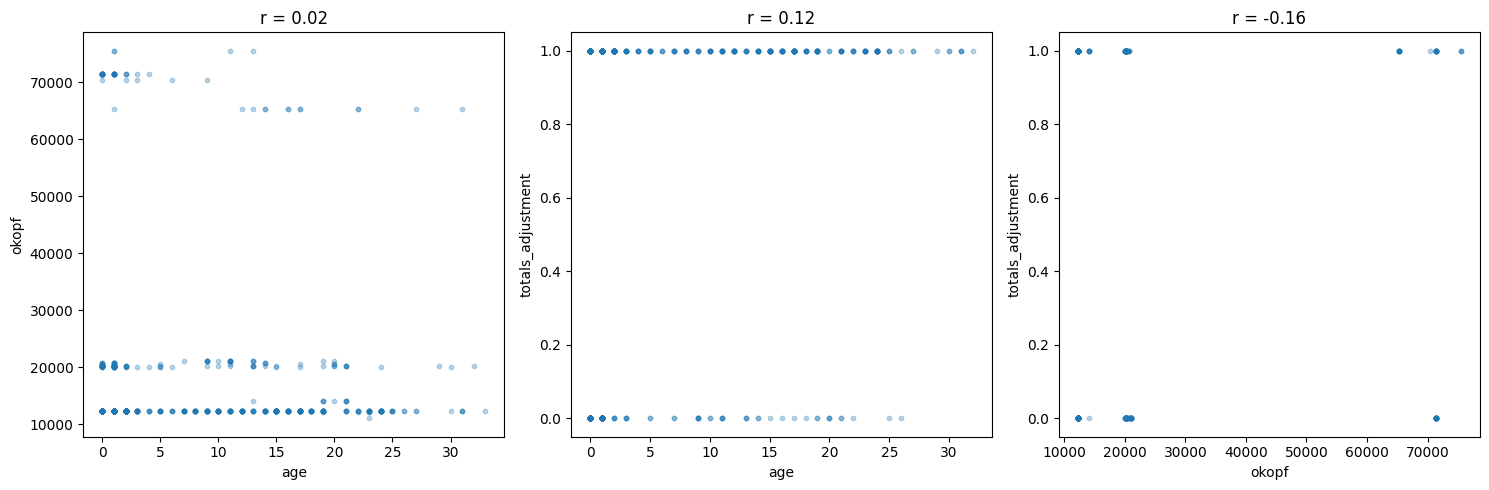

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [('age', 'okopf'), ('age', 'totals_adjustment'), ('okopf', 'totals_adjustment')]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.3, s=10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    corr = df[x].corr(df[y])
    ax.set_title(f'r = {corr:.2f}')

plt.tight_layout()
plt.show()

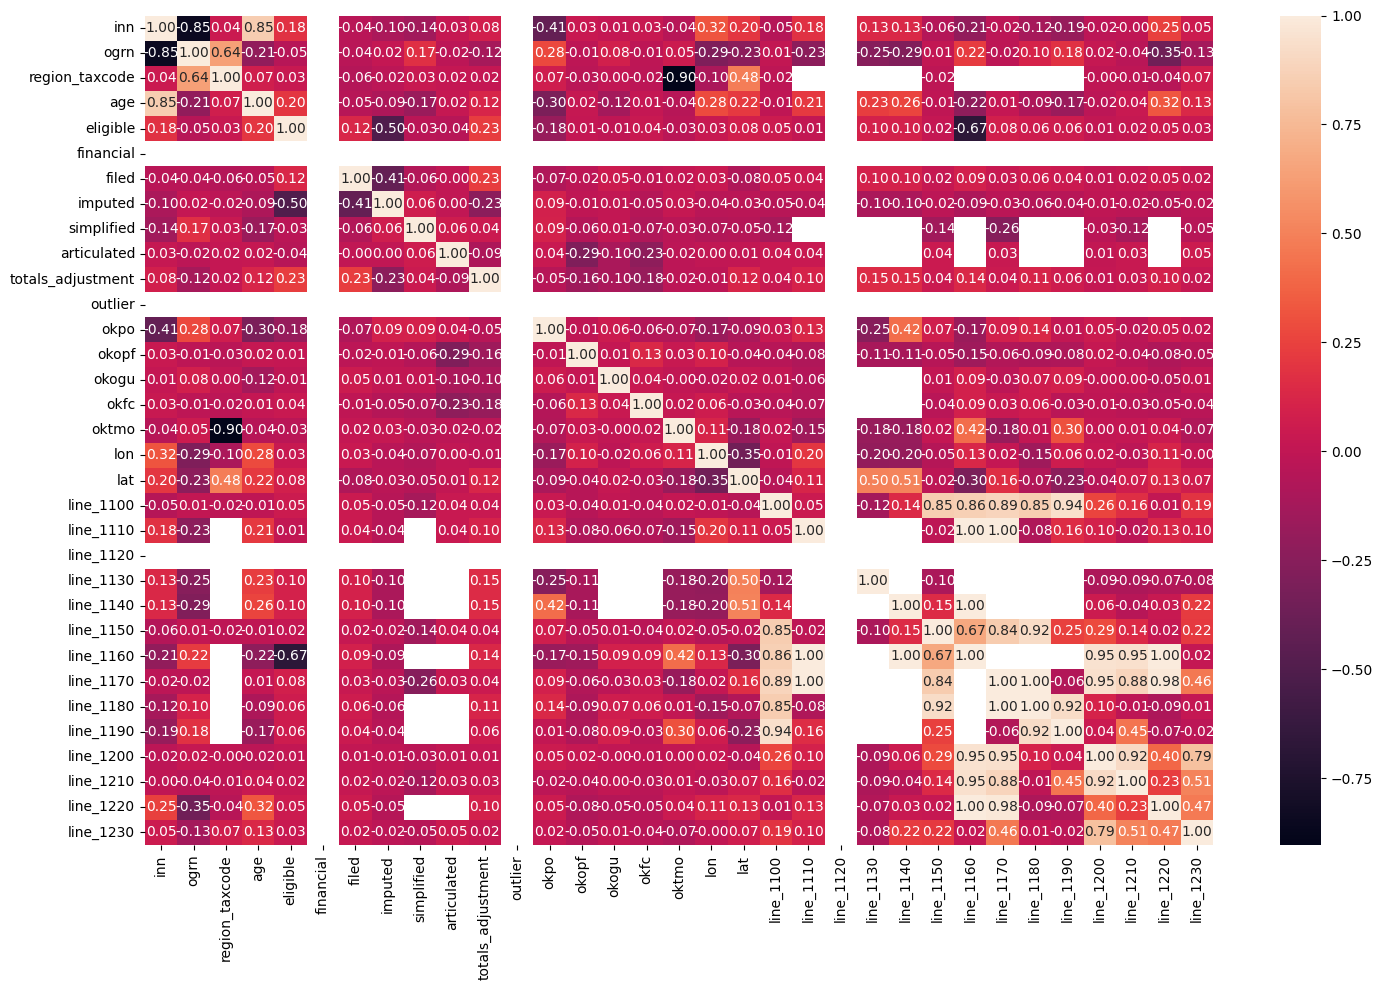

In [93]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.tight_layout()
plt.show()

##### Я не обрезал, но работаю в рамках 20-ти колонок
### Высокая корреляция между:
line_1100: line_1150, line_1160, line_1170, line_1180, line_1190

line_1160/line1170: lint 1200, line_1210, line_1220

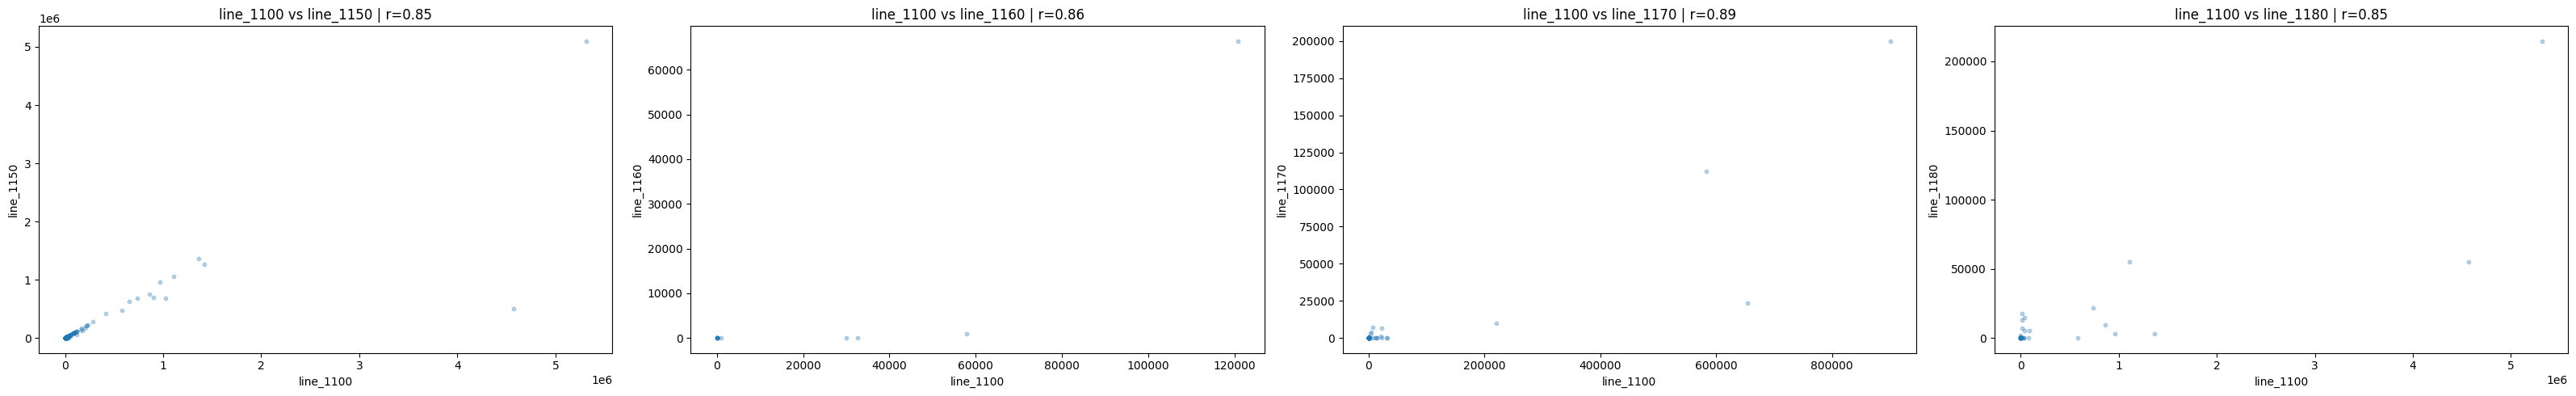

In [110]:
pairs = [('line_1100', 'line_1150'), ('line_1100', 'line_1160'), ('line_1100', 'line_1170'), ('line_1100', 'line_1180')]

fig, axes = plt.subplots(1, len(pairs), figsize=(8*len(pairs), 5))

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.3, s=10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y} | r={df[x].corr(df[y]):.2f}')

plt.tight_layout()
plt.show()

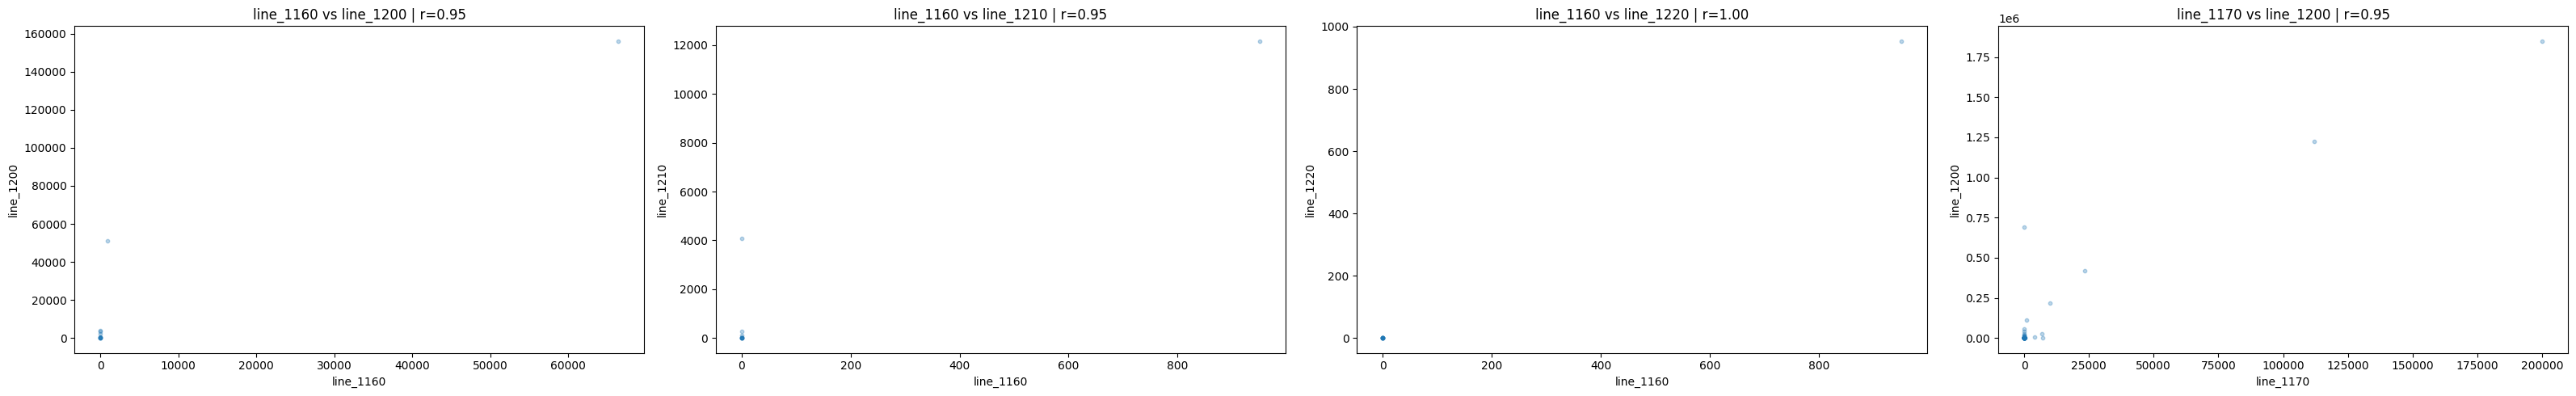

In [109]:
pairs = [('line_1160', 'line_1200'), ('line_1160', 'line_1210'), ('line_1160', 'line_1220'), ('line_1170', 'line_1200')]

fig, axes = plt.subplots(1, len(pairs), figsize=(8*len(pairs), 5))

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.3, s=10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y} | r={df[x].corr(df[y]):.2f}')

plt.tight_layout()
plt.show()

Мы не знаем для чего нужны эти колонки, к тому же они у некоторых записей пусты, а у некоторых имеют численное значение. Может эти колонки описаны в других отчетах бухгалтерии, но я не знаю их обозначения